# Gratis Fiyat Analizi — İndirim Tahmini (Deneysel Model)

**Notebook:** 05 — Makine Öğrenmesi ile Haftalık İndirim Tahmini  
**Proje:** Gratis'te Fiyat Davranışı Analizi

## Amaç

Bu notebook'ta geçmiş fiyat ve indirim verilerini kullanarak **bir sonraki haftanın ortalama indirim oranını** tahmin eden bir makine öğrenmesi modeli kurulur.

## Strateji

| | Tarih | Kullanım |
|---|---|---|
| **Train** | İlk 3 hafta (≈21 gün) | Modeli eğitmek için |
| **Validation** | Son 1 hafta (≈7 gün) | Tahminleri doğrulamak için |

## Model Yaklaşımı

- **Hedef değişken:** Gelecek 7 günün ortalama `indirim_yuzde` değeri
- **Özellikler:** Geçmiş lag değerleri, rolling ortalamalar, küme bilgisi, kategori
- **Algoritma:** Random Forest Regressor
- **Değerlendirme:** MAE, RMSE, R²

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Kütüphaneler yüklendi ✓')

Kütüphaneler yüklendi ✓


---

## 1) Veri Yükleme

In [5]:
DATA_DIR = Path('/Users/damlasimsek/Desktop/GRATİSVERİ/processed')

# Temiz gözlem verisi (günlük ürün-fiyat kayıtları)
df = pd.read_csv(DATA_DIR / 'gratis_clean.csv', encoding='utf-8-sig', parse_dates=['tarih'])

# Küme bilgisi
kume_df = pd.read_csv(DATA_DIR / 'urun_kumeleri.csv', encoding='utf-8-sig')
kume_map = kume_df.set_index('urun_id')[['cluster', 'cluster_adi']]

print(f'Temiz veri: {len(df):,} satır')
print(f'Tarih aralığı: {df["tarih"].min().date()} → {df["tarih"].max().date()}')
print(f'Ürün sayısı: {df["urun_id"].nunique():,}')
print()
df.head(3)

Temiz veri: 118,812 satır
Tarih aralığı: 2026-04-04 → 2026-05-06
Ürün sayısı: 10,628



,urun_id,isim,marka,kategori,fiyat,eski_fiyat,indirim_yuzde,kampanya,yorum_sayisi,begeni,url,tarih,kayit_zamani,snapshot_gun,begeni_sayi,indirimde_mi
0,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,180.0,451.0,60.1,250 TL ve Üzeri Alışverişe,10,6B,https://www.gratis.com/set-boyalar/palette-del...,2026-04-04 19:09:00,2026-04-04 19:28:27.007455,2026-04-04,6000.0,True
1,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,359.0,451.0,20.4,Kampanya Yok,10,6B,https://www.gratis.com/set-boyalar/palette-del...,2026-04-05 23:33:00,2026-04-05 23:45:32.052118,2026-04-05,6000.0,True
2,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,359.0,451.0,20.4,Kampanya Yok,10,6B,https://www.gratis.com/set-boyalar/palette-del...,2026-04-06 22:39:00,2026-04-06 23:02:24.419605,2026-04-06,6000.0,True


---

## 2) Train / Validation Bölünmesi

Toplam ~33 günlük veri:
- **Train:** İlk 3 hafta (min_tarih + 21 gün)
- **Validation:** Son 7 gün

Her ürün için günlük `indirim_yuzde` ortalaması alınarak ürün-gün pivot tablosu oluşturulur.

Toplam gün sayısı    : 33
Train süresi         : 2026-04-04 → 2026-04-27 (561 gün)
Validation süresi    : 2026-05-03 → 2026-05-06 (120 gün)
Train kayıt sayısı   : 94,150
Validation kayıt sayısı: 24,662


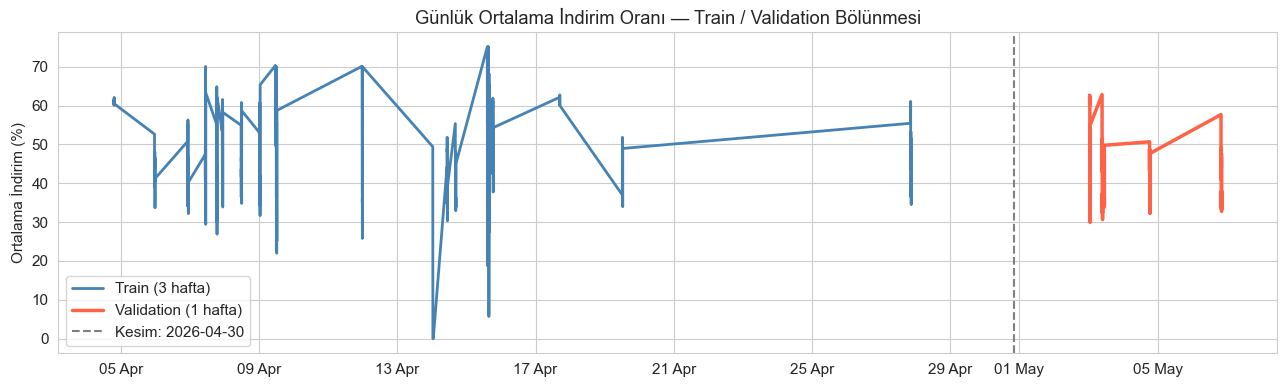

In [6]:
min_tarih = df['tarih'].min()
max_tarih = df['tarih'].max()
toplam_gun = (max_tarih - min_tarih).days + 1

# Kesim noktası: son 7 gün validation
kesim_tarihi = max_tarih - pd.Timedelta(days=6)

train_df = df[df['tarih'] < kesim_tarihi].copy()
val_df   = df[df['tarih'] >= kesim_tarihi].copy()

print(f'Toplam gün sayısı    : {toplam_gun}')
print(f'Train süresi         : {train_df["tarih"].min().date()} → {train_df["tarih"].max().date()} ({train_df["tarih"].nunique()} gün)')
print(f'Validation süresi    : {val_df["tarih"].min().date()} → {val_df["tarih"].max().date()} ({val_df["tarih"].nunique()} gün)')
print(f'Train kayıt sayısı   : {len(train_df):,}')
print(f'Validation kayıt sayısı: {len(val_df):,}')

# Görsel: veri bölünmesi
gun_bazli = df.groupby('tarih')['indirim_yuzde'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
train_g = gun_bazli[gun_bazli['tarih'] < kesim_tarihi]
val_g   = gun_bazli[gun_bazli['tarih'] >= kesim_tarihi]

ax.plot(train_g['tarih'], train_g['indirim_yuzde'], color='steelblue', label='Train (3 hafta)', linewidth=2)
ax.plot(val_g['tarih'],   val_g['indirim_yuzde'],   color='tomato',    label='Validation (1 hafta)', linewidth=2.5)
ax.axvline(kesim_tarihi, color='gray', linestyle='--', linewidth=1.5, label=f'Kesim: {kesim_tarihi.date()}')
ax.set_title('Günlük Ortalama İndirim Oranı — Train / Validation Bölünmesi')
ax.set_ylabel('Ortalama İndirim (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend()
plt.tight_layout()
plt.show()

---

## 3) Özellik Mühendisliği

Her ürün için **train dönemi** üzerinden aşağıdaki özellikler hesaplanır:

| Özellik | Açıklama |
|---|---|
| `lag_1w_indirim` | Son 7 günün ortalama indirimi |
| `lag_2w_indirim` | 8-14. gün arası ortalama indirim |
| `lag_3w_indirim` | 15-21. gün arası ortalama indirim |
| `rolling_std_indirim` | Son 14 günün indirim standart sapması |
| `max_indirim_train` | Train dönemindeki maksimum indirim |
| `indirimli_gun_orani` | İndirimli geçen gün oranı |
| `kampanyali_gun_orani` | Kampanyalı geçen gün oranı |
| `cluster` | K-Means kümesi |
| `kategori_enc` | Encode edilmiş kategori |
| **`hedef`** | **Validation haftasının ortalama indirim oranı (tahmin edilecek)** |

In [7]:
# --- Her ürün için günlük ortalama al ---
def urun_gunluk_ortalama(df_in):
    return (
        df_in.groupby(['urun_id', 'tarih'])
        .agg(
            indirim=('indirim_yuzde', 'mean'),
            kampanya=('kampanya', lambda x: (x.notna() & (x != '')).mean())
        )
        .reset_index()
    )

train_pivot = urun_gunluk_ortalama(train_df)
val_pivot   = urun_gunluk_ortalama(val_df)

# --- Train: lag özellikleri ---
kesim_gun = kesim_tarihi

def lag_ozellikler(pivot, urun_ids, kesim):
    """Her ürün için lag ve istatistik özelliklerini hesapla."""
    kayitlar = []
    for uid in urun_ids:
        u = pivot[pivot['urun_id'] == uid].sort_values('tarih')
        if len(u) < 7:
            continue

        # Son 7 gün = lag_1w
        son_7  = u[u['tarih'] >= (kesim - pd.Timedelta(days=7))]
        # 8-14 gün = lag_2w
        son_14_7 = u[(u['tarih'] >= (kesim - pd.Timedelta(days=14))) &
                     (u['tarih'] <  (kesim - pd.Timedelta(days=7)))]
        # 15-21 gün = lag_3w
        son_21_14 = u[(u['tarih'] >= (kesim - pd.Timedelta(days=21))) &
                      (u['tarih'] <  (kesim - pd.Timedelta(days=14)))]

        lag1 = son_7['indirim'].mean()      if len(son_7) > 0 else np.nan
        lag2 = son_14_7['indirim'].mean()   if len(son_14_7) > 0 else np.nan
        lag3 = son_21_14['indirim'].mean()  if len(son_21_14) > 0 else np.nan

        # Son 14 günlük std
        son_14 = u[u['tarih'] >= (kesim - pd.Timedelta(days=14))]
        rolling_std = son_14['indirim'].std() if len(son_14) > 1 else 0.0

        kayitlar.append({
            'urun_id': uid,
            'lag_1w_indirim': lag1,
            'lag_2w_indirim': lag2,
            'lag_3w_indirim': lag3,
            'rolling_std_indirim': rolling_std,
            'max_indirim_train': u['indirim'].max(),
            'indirimli_gun_orani': (u['indirim'] > 0).mean(),
            'kampanyali_gun_orani': u['kampanya'].mean(),
            'gozlem_sayisi': len(u),
        })
    return pd.DataFrame(kayitlar)

urun_ids = train_pivot['urun_id'].unique()
print(f'Özellik hesaplanacak ürün sayısı: {len(urun_ids):,}')

ozellik_df = lag_ozellikler(train_pivot, urun_ids, kesim_tarihi)
print(f'Özellik tablosu oluşturuldu: {ozellik_df.shape}')

Özellik hesaplanacak ürün sayısı: 10,628
Özellik tablosu oluşturuldu: (9234, 9)


## Model Veri Seti Hazırlığı

Bu hücrede ham özellik tabloları birleştirilerek Random Forest modeline girecek nihai veri seti oluşturulmaktadır.

**Yapılan adımlar:**

1. **Hedef değişken:** Validation haftasındaki gerçek indirim oranlarının ürün bazında ortalaması alınarak `hedef_indirim` sütunu oluşturulmaktadır.

2. **Meta bilgi ekleme:** Her ürünün kategori ve küme (cluster) bilgisi ana tabloya eklenmektedir.

3. **Tablo birleştirme:** Özellik tablosu, hedef değişken ve meta bilgi `urun_id` üzerinden tek bir `model_df`'te birleştirilmektedir.

4. **Encoding:**
   - Kategori sütunu `LabelEncoder` ile sayısala çevrilmektedir
   - Küme bilgisi integer'a dönüştürülmekte, eksik değerler `-1` ile doldurulmaktadır

5. **Lag değişkeni doldurma:** 2. ve 3. hafta gecikmeli indirim değerleri eksikse, mevcut en yakın değer olan `lag_1w_indirim` ile tamamlanmaktadır.

6. **Temizlik:** `lag_1w_indirim` veya `hedef_indirim` değeri eksik olan ürünler çıkarılmaktadır — bu ürünler model için yeterli geçmişe sahip değildir.

In [14]:
# --- Hedef değişken: validation haftası ortalama indirimi ---
hedef_df = (
    val_pivot.groupby('urun_id')['indirim']
    .mean()
    .reset_index()
    .rename(columns={'indirim': 'hedef_indirim'})
)

# --- Küme ve kategori bilgisi ---
meta_df = df[['urun_id', 'kategori']].drop_duplicates('urun_id')
meta_df = meta_df.merge(kume_map.reset_index(), on='urun_id', how='left')

# --- Tüm tabloları birleştir ---
model_df = (
    ozellik_df
    .merge(hedef_df, on='urun_id', how='inner')
    .merge(meta_df,  on='urun_id', how='left')
)

# Kategori encode
le_kat = LabelEncoder()
model_df['kategori_enc'] = le_kat.fit_transform(model_df['kategori'].fillna('Bilinmiyor'))

# Küme sayısal
model_df['cluster'] = model_df['cluster'].fillna(-1).astype(int)

# Sadece lag_1w zorunlu, diğerleri eksikse 0 ile doldur
model_df['lag_2w_indirim'] = model_df['lag_2w_indirim'].fillna(model_df['lag_1w_indirim'])
model_df['lag_3w_indirim'] = model_df['lag_3w_indirim'].fillna(model_df['lag_1w_indirim'])

model_df_clean = model_df.dropna(subset=['lag_1w_indirim', 'hedef_indirim'])

print(f'Model verisi: {len(model_df_clean):,} ürün')
print(f'Düşürülen ürün: {len(model_df) - len(model_df_clean):,} (yetersiz geçmiş)')
model_df_clean.head(3)

Model verisi: 6,457 ürün
Düşürülen ürün: 2,415 (yetersiz geçmiş)


,urun_id,lag_1w_indirim,lag_2w_indirim,lag_3w_indirim,rolling_std_indirim,max_indirim_train,indirimli_gun_orani,kampanyali_gun_orani,gozlem_sayisi,hedef_indirim,kategori,cluster,cluster_adi,kategori_enc
0,10000049,20.4,40.25,20.4,22.920806,60.1,1.000,1.0,12,20.4,Saç Bakım,0,Sürekli İndirimli Ana Katalog Ürünleri,12
1,10000236,0.0,0.00,0.0,0.000000,60.1,0.125,1.0,8,0.0,Makyaj,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,9
2,10000237,0.0,0.00,0.0,0.000000,70.1,0.250,1.0,8,0.0,Makyaj,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,9


---

## 4) Model Eğitimi — Random Forest

**Tüm train verisi** model eğitiminde kullanılır. **Validation haftası** tahmin için ayrılmıştır.

In [25]:
FEATURE_COLS = [
    'lag_1w_indirim',
    'lag_2w_indirim',
    'lag_3w_indirim',
    'rolling_std_indirim',
    'max_indirim_train',
    'indirimli_gun_orani',
    'kampanyali_gun_orani',
    'gozlem_sayisi',
    'cluster',
    'kategori_enc',
]
TARGET_COL = 'hedef_indirim'

X = model_df_clean[FEATURE_COLS].fillna(0)
y = model_df_clean[TARGET_COL]

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X, y)

print('Model eğitimi tamamlandı ✓')
print(f'Eğitim örnek sayısı: {len(X):,}')

Model eğitimi tamamlandı ✓
Eğitim örnek sayısı: 6,457


---

## 5) Model Değerlendirmesi

Validation haftasındaki **gerçek** indirim ortalamaları ile **tahmin** edilen değerler karşılaştırılır.

In [28]:
indirim_var_mi = clf.predict(X)

y_pred = rf_model.predict(X)

mae  = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2   = r2_score(y, y_pred)

print('=== MODEL PERFORMANSI (Validation Haftası) ===')
print(f'MAE  (Ortalama Mutlak Hata)      : {mae:.2f} puan')
print(f'RMSE (Karekök Ortalama Kare Hata): {rmse:.2f} puan')
print(f'R²   (Açıklanan Varyans)         : {r2:.4f}')
print()
print('Yorum: Model ortalama olarak validation haftasındaki indirim oranını')
print(f'       ±{mae:.1f} puan hata payıyla tahmin edebilmektedir.')

=== MODEL PERFORMANSI (Validation Haftası) ===
MAE  (Ortalama Mutlak Hata)      : 2.25 puan
RMSE (Karekök Ortalama Kare Hata): 4.55 puan
R²   (Açıklanan Varyans)         : 0.9224

Yorum: Model ortalama olarak validation haftasındaki indirim oranını
       ±2.2 puan hata payıyla tahmin edebilmektedir.


## Model Performans Görselleştirmesi

Bu bölümde eğitilen regresyon modelinin tahmin kalitesi iki farklı görsel üzerinden incelenmektedir.

**Sol grafik — Gerçek vs Tahmin:**  
Her nokta bir ürünü temsil etmektedir. Yatay eksen gerçek indirim oranını, dikey eksen ise modelin tahminini göstermektedir. Kırmızı kesik çizgi mükemmel tahmini simgeler — noktalar bu çizgiye ne kadar yakınsa model o kadar başarılıdır.

**Sağ grafik — Hata Dağılımı:**  
Tahmin hatası `(tahmin − gerçek)` hesaplanarak histogram olarak çizilmektedir. İdeal bir modelde bu dağılım sıfır etrafında simetrik ve dar olmalıdır. Ortalama ve standart sapma değerleri başlıkta gösterilmektedir:
- **Ortalama ≈ 0** → model sistematik olarak ne aşırı ne eksik tahmin yapıyor
- **Küçük std** → tahminler gerçek değerlere yakın yığılıyor

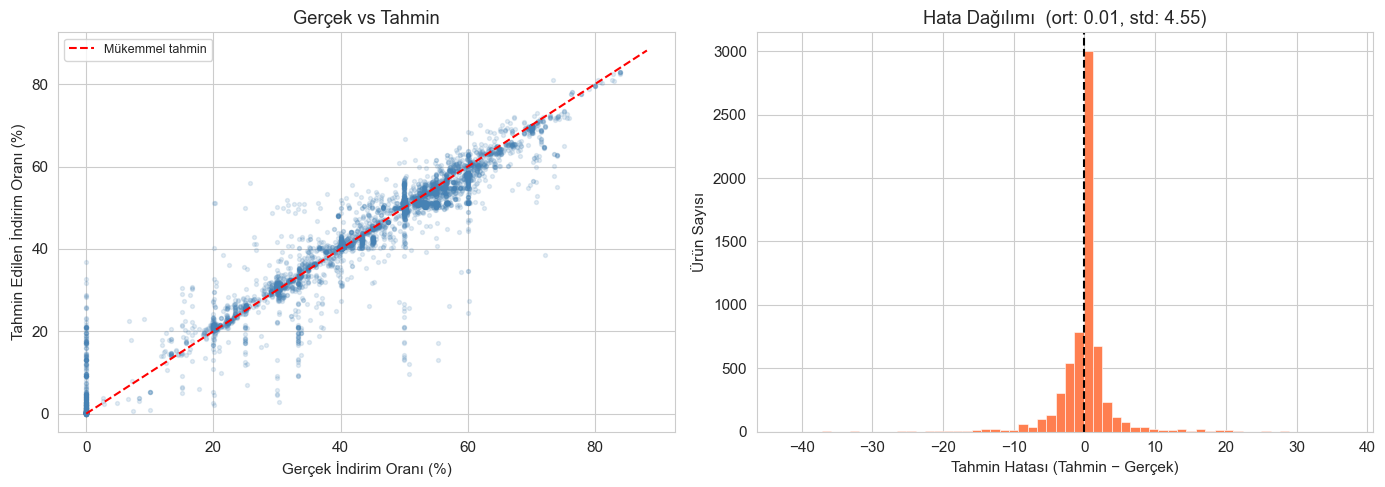

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gerçek vs Tahmin scatter
ax1 = axes[0]
ax1.scatter(y, y_pred, alpha=0.15, s=8, color='steelblue')
lim = max(y.max(), y_pred.max()) * 1.05
ax1.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Mükemmel tahmin')
ax1.set_xlabel('Gerçek İndirim Oranı (%)')
ax1.set_ylabel('Tahmin Edilen İndirim Oranı (%)')
ax1.set_title('Gerçek vs Tahmin')
ax1.legend(fontsize=9)

# Hata dağılımı
ax2 = axes[1]
hatalar = y_pred - y
ax2.hist(hatalar, bins=60, color='coral', edgecolor='white', linewidth=0.4)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Tahmin Hatası (Tahmin − Gerçek)')
ax2.set_ylabel('Ürün Sayısı')
ax2.set_title(f'Hata Dağılımı  (ort: {hatalar.mean():.2f}, std: {hatalar.std():.2f})')

plt.tight_layout()
plt.show()

---

## 6) Özellik Önemi

## Özellik Önemi Analizi

Bu bölümde Random Forest modelinin hangi değişkenlere ne kadar ağırlık verdiği incelenmektedir.

**Grafik:** Her özelliğin Gini safsızlık azaltma skoruna göre sıralanmış yatay bar grafiği.  
Bir özelliğin skoru ne kadar yüksekse, model karar ağaçlarında o özelliği o kadar sık ve kritik noktalarda kullanıyor demektir.

**`print` çıktısı:** Görsel tamamlandıktan sonra aynı tablo sayısal olarak da yazdırılmaktadır — kesin değerleri not almak veya raporlamak için kullanışlıdır.

**Yorumlama rehberi:**
- **Üst sıradaki özellikler** → modelin tahmin gücünün büyük bölümünü taşıyan değişkenler
- **Alt sıradaki özellikler** → modele katkısı sınırlı; gerekirse çıkarılabilir (model sadeleştirme)
- Gini skoru tüm ağaçlar üzerinden ortalama alındığından tek bir ağaca göre daha güvenilirdir

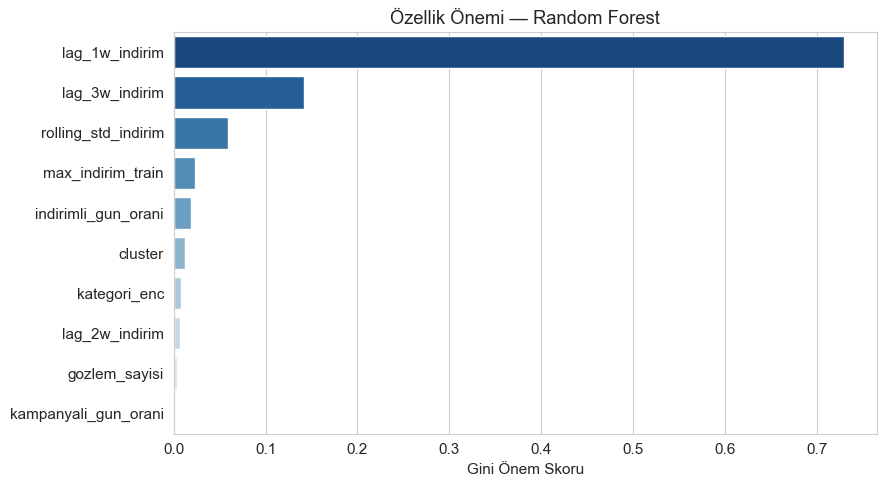

             ozellik     onem
      lag_1w_indirim 0.728966
      lag_3w_indirim 0.141551
 rolling_std_indirim 0.058532
   max_indirim_train 0.023272
 indirimli_gun_orani 0.018385
             cluster 0.012026
        kategori_enc 0.007505
      lag_2w_indirim 0.006474
       gozlem_sayisi 0.003289
kampanyali_gun_orani 0.000000


In [30]:
importance_df = pd.DataFrame({
    'ozellik': FEATURE_COLS,
    'onem'   : rf_model.feature_importances_
}).sort_values('onem', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=importance_df, y='ozellik', x='onem', palette='Blues_r', ax=ax)
ax.set_title('Özellik Önemi — Random Forest')
ax.set_xlabel('Gini Önem Skoru')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

---

## 7) Bir Sonraki Hafta Tahmini

Model artık eğitildi. **Şu anki son haftanın** verilerini lag özellikleri olarak kullanarak **gelecek 7 günün tahmini** yapılabilir.

> **Not:** Bu tahmin, mevcut en güncel veriyi (son 7 gün) özellik olarak kullanır. Yeni veri çekildikçe model yeniden çalıştırılabilir.

In [31]:
# Tüm veriyi kullanarak özellik üret (son 3 hafta = son 21 gün)
# Bu sefer kesim tarihi = max_tarih + 1 gün (hayali kesim)
gelecek_kesim = max_tarih + pd.Timedelta(days=1)

tum_pivot = urun_gunluk_ortalama(df)
tum_urun_ids = tum_pivot['urun_id'].unique()

print(f'Gelecek hafta tahmini yapılacak ürün sayısı: {len(tum_urun_ids):,}')
print('Özellikler hesaplanıyor...')

gelecek_ozellik_df = lag_ozellikler(tum_pivot, tum_urun_ids, gelecek_kesim)

# Meta bilgileri ekle
gelecek_ozellik_df = gelecek_ozellik_df.merge(meta_df, on='urun_id', how='left')
gelecek_ozellik_df['kategori_enc'] = le_kat.transform(
    gelecek_ozellik_df['kategori'].fillna('Bilinmiyor').map(
        lambda x: x if x in le_kat.classes_ else le_kat.classes_[0]
    )
)
gelecek_ozellik_df['cluster'] = gelecek_ozellik_df['cluster'].fillna(-1).astype(int)

X_gelecek = gelecek_ozellik_df[FEATURE_COLS].fillna(0)
gelecek_ozellik_df['tahmini_indirim'] = rf_model.predict(X_gelecek)

# Ürün adı ve marka ekle
urun_meta = df[['urun_id', 'isim', 'marka', 'kategori']].drop_duplicates('urun_id')
sonuc_df = gelecek_ozellik_df.merge(urun_meta, on='urun_id', how='left')

print(f'\nTahmin tamamlandı ✓ — {len(sonuc_df):,} ürün için gelecek hafta tahmini yapıldı.')

Gelecek hafta tahmini yapılacak ürün sayısı: 10,628
Özellikler hesaplanıyor...

Tahmin tamamlandı ✓ — 10,088 ürün için gelecek hafta tahmini yapıldı.


## Gelecek Hafta Tahmin Sonuçlarının Görselleştirilmesi

Bu bölümde modelin ürettiği indirim tahminleri üç farklı perspektiften görselleştirilmektedir.

---

**1. Kategori Bazında Analiz (Bar + Heatmap)**

- **Sol — Yatay Bar Grafik:** Kategori bazında ortalama tahmini indirimi göstermektedir. Renkler kırmızıdan yeşile giderek indirim yoğunluğunu temsil eder; en yüksek indirim beklenen kategoriler üstte yer alır.
- **Sağ — Küme × Kategori Heatmap:** Her kümenin kategoriler genelindeki tahmini indirim dağılımını göstermektedir. Koyu hücreler yüksek indirim beklentisine işaret eder; hangi kümenin hangi kategoride baskın olduğu tek bakışta görülebilir.

---

**2. Marka Bazında Top 15**

Gelecek hafta en yüksek ortalama indirim beklenen ilk 15 marka listelenmektedir. Satın alma kararlarında marka önceliği olan kullanıcılar için yönlendirici bir çıktıdır.

---

**3. Tahmin Dağılımı**

- **Sol — Histogram:** Tüm ürünlerin tahmini indirim dağılımını göstermektedir. Kırmızı kesik çizgi genel ortalamayı işaretler; dağılımın şekli modelin ne kadar çeşitli tahminler ürettiğini ortaya koyar.
- **Sağ — Küme Bazında Bar:** Üç kümenin ortalama tahmini indirimleri karşılaştırılmaktadır. Kümeler arasındaki fark, segmentasyonun tahmin üzerindeki etkisini somutlaştırır.

---

**Özet Çıktı:** Kod sonunda yazdırılan özet, tahmin yapılan toplam ürün sayısını, ortalama ve maksimum tahmini indirimi ve %10 üzeri indirim beklenen ürün sayısını raporlamaktadır.

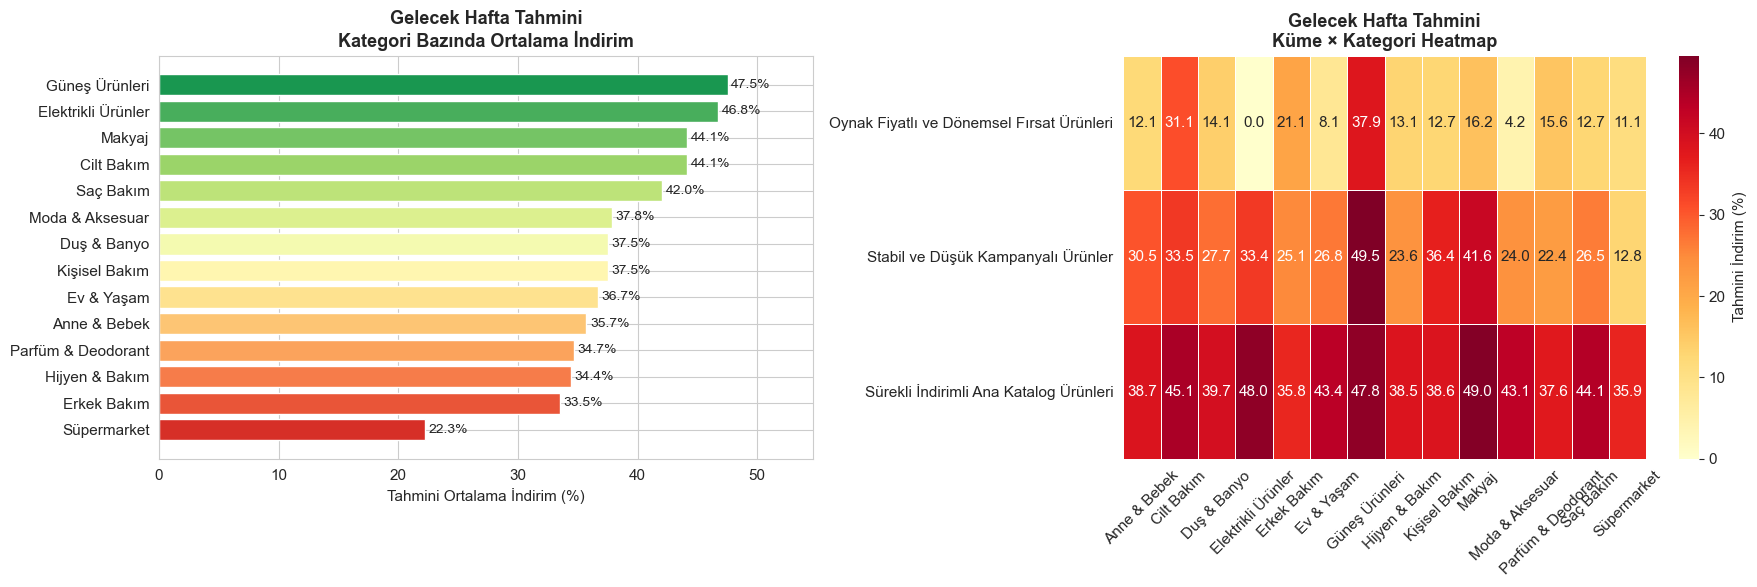

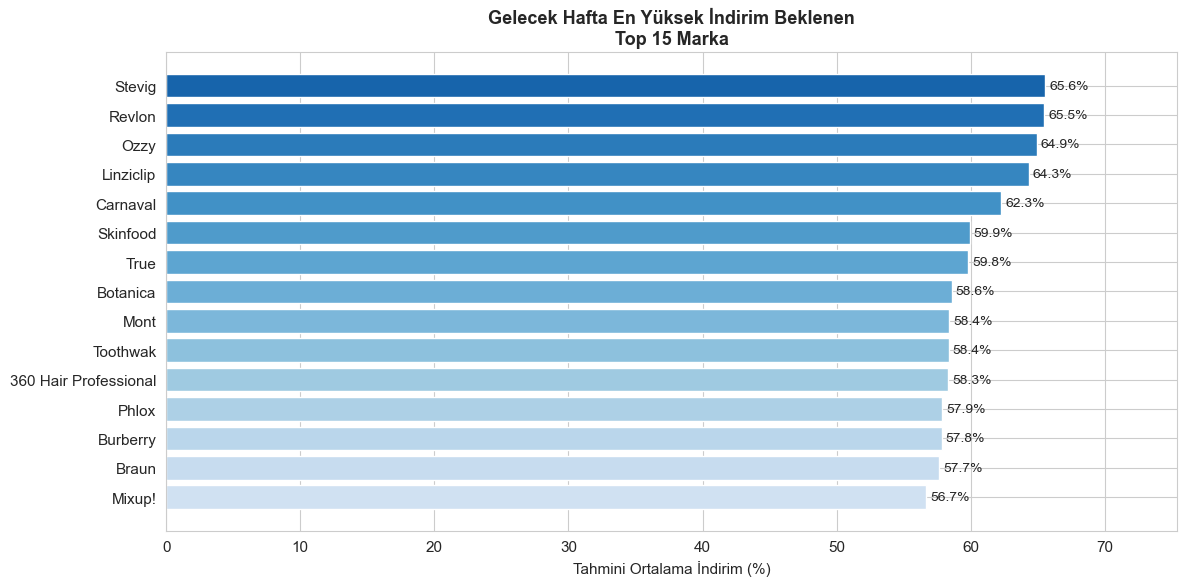

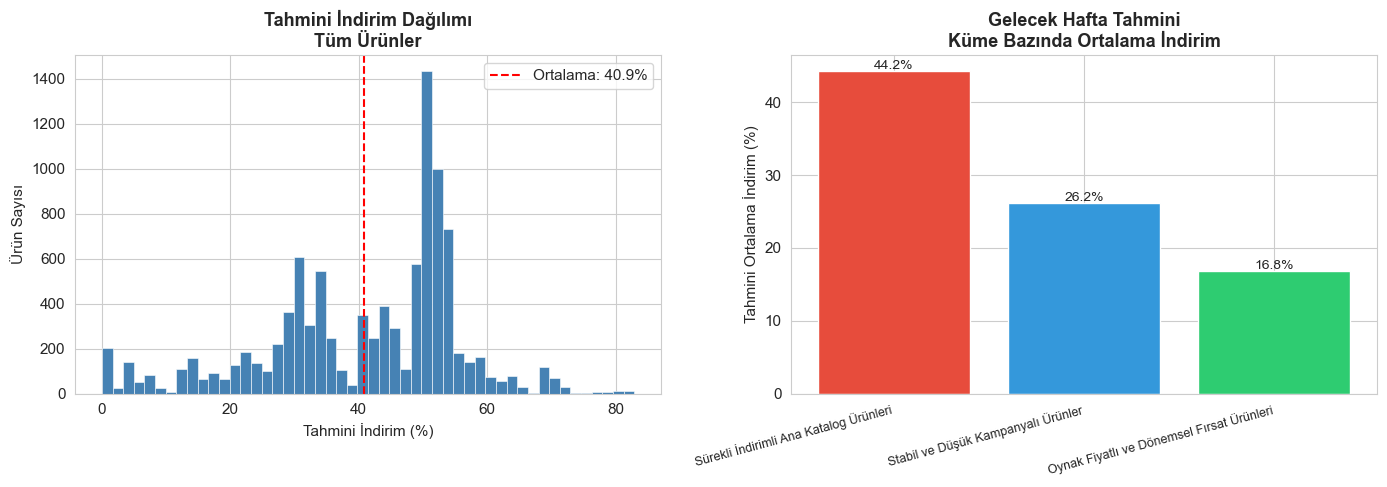


=== ÖZET ===
Tahmin yapılan ürün sayısı : 10,088
Ortalama tahmini indirim   : %40.9
En yüksek tahmini indirim  : %82.9
İndirim beklenen ürün sayısı (>%10): 9,563


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Kategori sütununu düzelt
sonuc_df['kategori'] = sonuc_df['kategori_y'].fillna(sonuc_df['kategori_x'])

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# === 1) KATEGORİ BAZINDA BAR + KÜME×KATEGORİ HEATMAP ===
kat_hafta = (
    sonuc_df.groupby('kategori')['tahmini_indirim']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax1 = axes[0]
bars = ax1.barh(kat_hafta['kategori'], kat_hafta['tahmini_indirim'],
                color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(kat_hafta))))
ax1.set_title('Gelecek Hafta Tahmini\nKategori Bazında Ortalama İndirim', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tahmini Ortalama İndirim (%)')
ax1.set_xlim(0, kat_hafta['tahmini_indirim'].max() * 1.15)
for bar, val in zip(ax1.patches, kat_hafta['tahmini_indirim']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)
ax1.invert_yaxis()

kume_kat = (
    sonuc_df.groupby(['cluster_adi', 'kategori'])['tahmini_indirim']
    .mean()
    .unstack(fill_value=0)
)

ax2 = axes[1]
sns.heatmap(kume_kat, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax2, cbar_kws={'label': 'Tahmini İndirim (%)'})
ax2.set_title('Gelecek Hafta Tahmini\nKüme × Kategori Heatmap', fontsize=13, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# === 2) MARKA BAZINDA TOP 15 ===
marka_hafta = (
    sonuc_df.groupby('marka')['tahmini_indirim']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(marka_hafta['marka'], marka_hafta['tahmini_indirim'],
               color=plt.cm.Blues_r(np.linspace(0.2, 0.8, len(marka_hafta))))
ax.set_title('Gelecek Hafta En Yüksek İndirim Beklenen\nTop 15 Marka', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmini Ortalama İndirim (%)')
ax.set_xlim(0, marka_hafta['tahmini_indirim'].max() * 1.15)
for bar, val in zip(ax.patches, marka_hafta['tahmini_indirim']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# === 3) TAHMİN DAĞILIMI HISTOGRAM ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(sonuc_df['tahmini_indirim'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax1.set_title('Tahmini İndirim Dağılımı\nTüm Ürünler', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tahmini İndirim (%)')
ax1.set_ylabel('Ürün Sayısı')
ax1.axvline(sonuc_df['tahmini_indirim'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Ortalama: {sonuc_df["tahmini_indirim"].mean():.1f}%')
ax1.legend()

ax2 = axes[1]
kume_sirali = sonuc_df.groupby('cluster_adi')['tahmini_indirim'].mean().sort_values(ascending=False)
colors = ['#e74c3c', '#3498db', '#2ecc71']
ax2.bar(range(len(kume_sirali)), kume_sirali.values, color=colors)
ax2.set_xticks(range(len(kume_sirali)))
ax2.set_xticklabels(kume_sirali.index, rotation=15, ha='right', fontsize=9)
ax2.set_title('Gelecek Hafta Tahmini\nKüme Bazında Ortalama İndirim', fontsize=13, fontweight='bold')
ax2.set_ylabel('Tahmini Ortalama İndirim (%)')
for i, val in enumerate(kume_sirali.values):
    ax2.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'\n=== ÖZET ===')
print(f'Tahmin yapılan ürün sayısı : {len(sonuc_df):,}')
print(f'Ortalama tahmini indirim   : %{sonuc_df["tahmini_indirim"].mean():.1f}')
print(f'En yüksek tahmini indirim  : %{sonuc_df["tahmini_indirim"].max():.1f}')
print(f'İndirim beklenen ürün sayısı (>%10): {(sonuc_df["tahmini_indirim"] > 10).sum():,}')

HANGİ ÜRÜNLERİN İNDİRİME GİRECEĞİNİ SÖYLEYEN KOD 

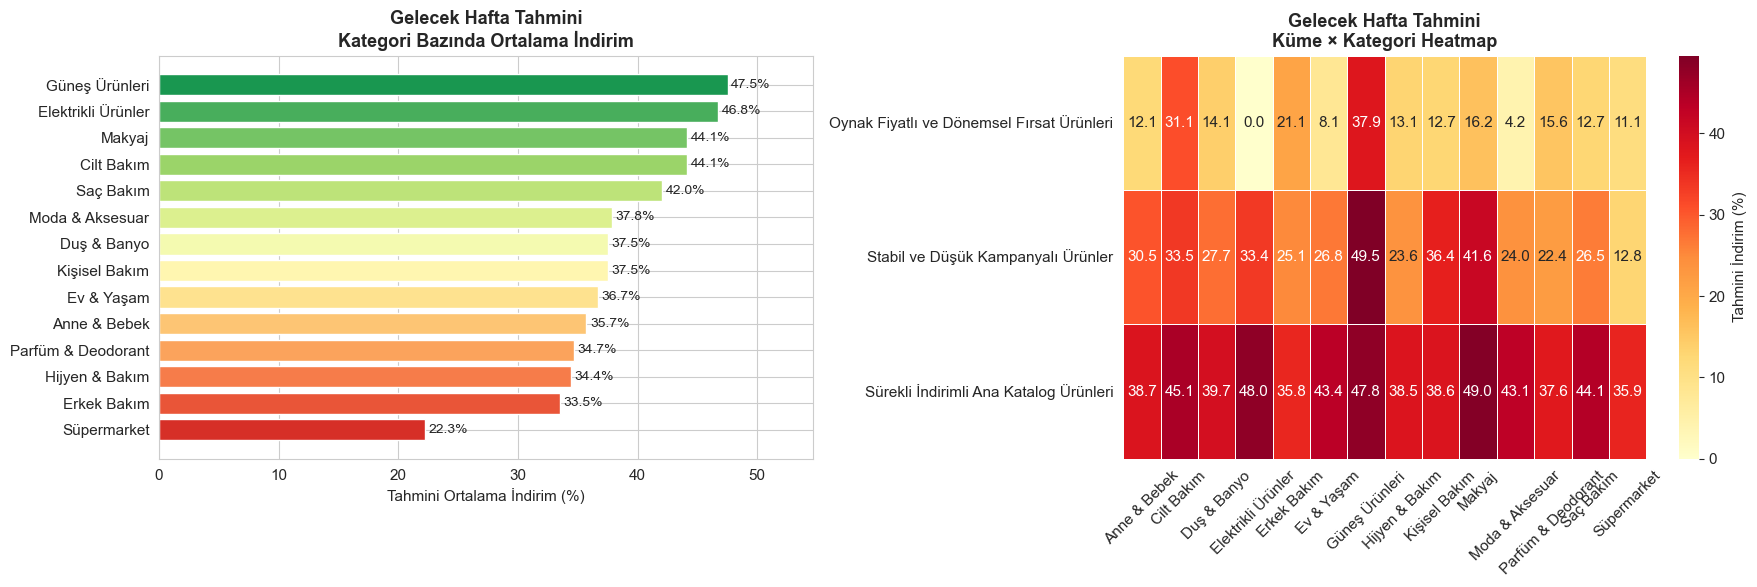

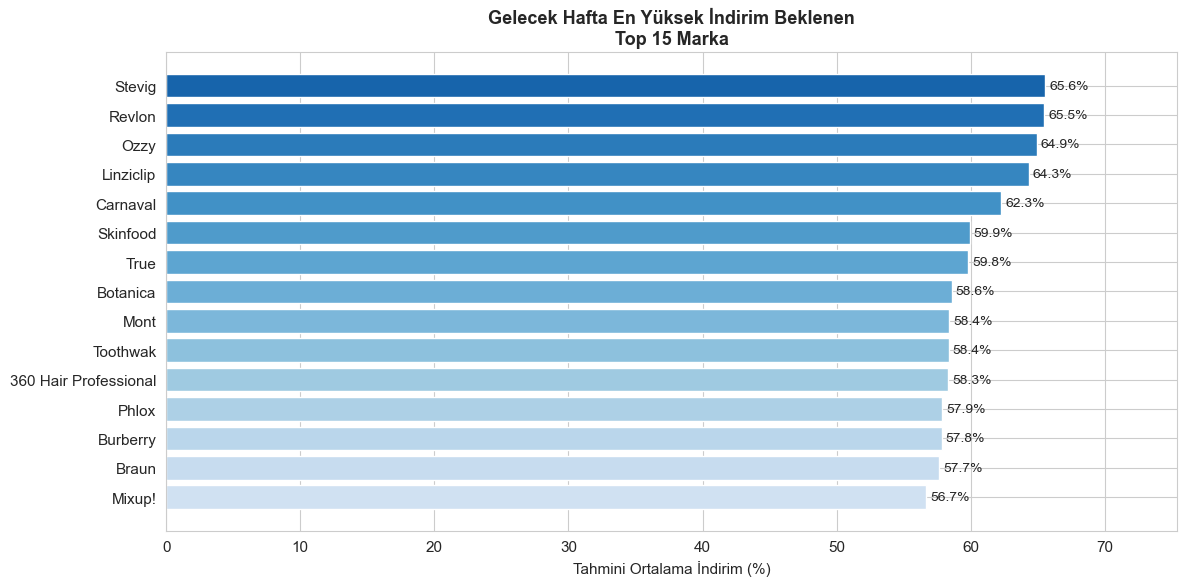

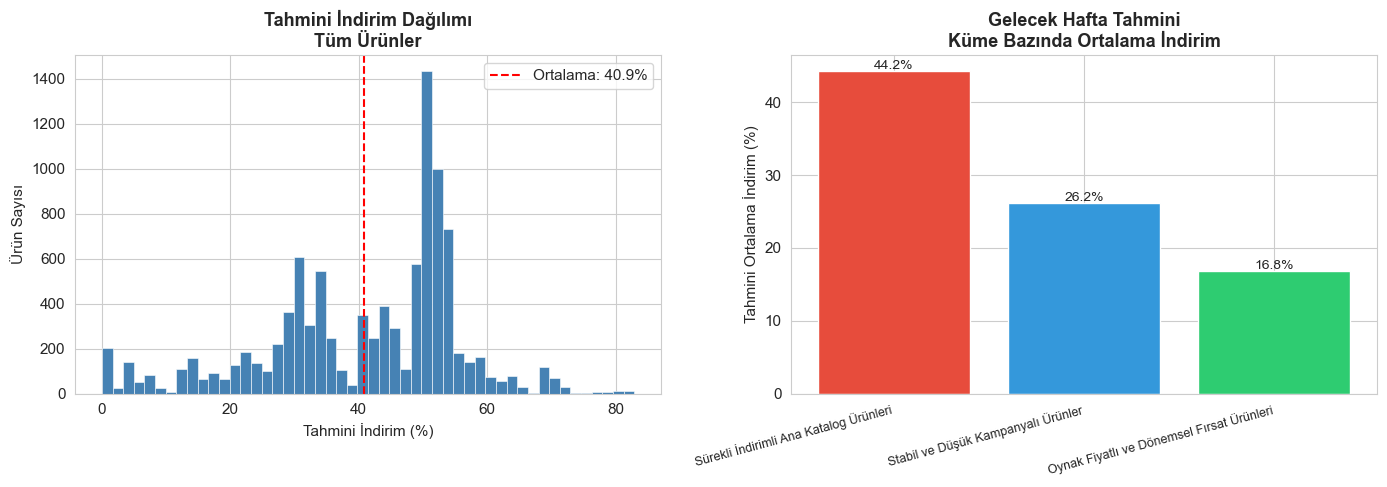


=== ÖZET ===
Tahmin yapılan ürün sayısı : 10,088
Ortalama tahmini indirim   : %40.9
En yüksek tahmini indirim  : %82.9
İndirim beklenen ürün sayısı (>%10): 9,563


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Kategori sütununu düzelt
sonuc_df['kategori'] = sonuc_df['kategori_y'].fillna(sonuc_df['kategori_x'])

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# === 1) KATEGORİ BAZINDA BAR + KÜME×KATEGORİ HEATMAP ===
kat_hafta = (
    sonuc_df.groupby('kategori')['tahmini_indirim']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax1 = axes[0]
bars = ax1.barh(kat_hafta['kategori'], kat_hafta['tahmini_indirim'],
                color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(kat_hafta))))
ax1.set_title('Gelecek Hafta Tahmini\nKategori Bazında Ortalama İndirim', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tahmini Ortalama İndirim (%)')
ax1.set_xlim(0, kat_hafta['tahmini_indirim'].max() * 1.15)
for bar, val in zip(ax1.patches, kat_hafta['tahmini_indirim']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)
ax1.invert_yaxis()

kume_kat = (
    sonuc_df.groupby(['cluster_adi', 'kategori'])['tahmini_indirim']
    .mean()
    .unstack(fill_value=0)
)

ax2 = axes[1]
sns.heatmap(kume_kat, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax2, cbar_kws={'label': 'Tahmini İndirim (%)'})
ax2.set_title('Gelecek Hafta Tahmini\nKüme × Kategori Heatmap', fontsize=13, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# === 2) MARKA BAZINDA TOP 15 ===
marka_hafta = (
    sonuc_df.groupby('marka')['tahmini_indirim']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(marka_hafta['marka'], marka_hafta['tahmini_indirim'],
               color=plt.cm.Blues_r(np.linspace(0.2, 0.8, len(marka_hafta))))
ax.set_title('Gelecek Hafta En Yüksek İndirim Beklenen\nTop 15 Marka', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmini Ortalama İndirim (%)')
ax.set_xlim(0, marka_hafta['tahmini_indirim'].max() * 1.15)
for bar, val in zip(ax.patches, marka_hafta['tahmini_indirim']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# === 3) TAHMİN DAĞILIMI HISTOGRAM ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(sonuc_df['tahmini_indirim'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax1.set_title('Tahmini İndirim Dağılımı\nTüm Ürünler', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tahmini İndirim (%)')
ax1.set_ylabel('Ürün Sayısı')
ax1.axvline(sonuc_df['tahmini_indirim'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Ortalama: {sonuc_df["tahmini_indirim"].mean():.1f}%')
ax1.legend()

ax2 = axes[1]
kume_sirali = sonuc_df.groupby('cluster_adi')['tahmini_indirim'].mean().sort_values(ascending=False)
colors = ['#e74c3c', '#3498db', '#2ecc71']
ax2.bar(range(len(kume_sirali)), kume_sirali.values, color=colors)
ax2.set_xticks(range(len(kume_sirali)))
ax2.set_xticklabels(kume_sirali.index, rotation=15, ha='right', fontsize=9)
ax2.set_title('Gelecek Hafta Tahmini\nKüme Bazında Ortalama İndirim', fontsize=13, fontweight='bold')
ax2.set_ylabel('Tahmini Ortalama İndirim (%)')
for i, val in enumerate(kume_sirali.values):
    ax2.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'\n=== ÖZET ===')
print(f'Tahmin yapılan ürün sayısı : {len(sonuc_df):,}')
print(f'Ortalama tahmini indirim   : %{sonuc_df["tahmini_indirim"].mean():.1f}')
print(f'En yüksek tahmini indirim  : %{sonuc_df["tahmini_indirim"].max():.1f}')
print(f'İndirim beklenen ürün sayısı (>%10): {(sonuc_df["tahmini_indirim"] > 10).sum():,}')

## Doğruluk Analizi ve Ürün Bazlı Rapor

Bu bölümde modelin validation haftasındaki gerçek indirim değerleriyle karşılaştırılması yapılmakta ve tahmin doğruluğu çok boyutlu olarak raporlanmaktadır.

---

**Yapılan adımlar:**

1. **Gerçek değerlerin hazırlanması:** Validation haftasındaki gerçek indirim oranları ürün bazında ortalaması alınarak `gercek_df` tablosuna aktarılmaktadır.

2. **Karşılaştırma tablosu:** Tahmin sonuçları gerçek değerlerle birleştirilmekte; her ürün için mutlak hata ve `±5 puan tolerans` kriterine göre doğru/yanlış etiketi hesaplanmaktadır.

3. **İndirime girecek ürün listesi:** Tahmini indirimi `%10` üzerinde olan ürünler listelenmekte ve ilk 30 tanesi ekrana yazdırılmaktadır.

4. **Genel doğruluk özeti:** Tüm ürünler üzerinde kaç tanesinin tolerans dahilinde doğru tahmin edildiği yüzdesel olarak raporlanmaktadır.

---

**Görseller:**

- **Sol — Pasta Grafiği:** Doğru ve yanlış tahmin edilen ürünlerin oranını göstermektedir. Yeşil doğru, kırmızı yanlış tahmini temsil eder.

- **Orta — Hata Dağılımı Histogramı:** Tüm ürünlerdeki mutlak hata değerlerinin dağılımını göstermektedir. Kırmızı çizgi `±5` puan tolerans sınırını, turuncu çizgi ise ortalama hatayı işaretlemektedir.

- **Sağ — Kategori Bazında Doğruluk:** Her kategorinin doğruluk oranı yatay bar grafiğiyle sunulmaktadır. Renkler performans seviyesine göre değişir: kırmızı `<%70`, turuncu `%70–85`, yeşil `>%85`.

- **Son Grafik — Marka Bazında Top 15:** En az 5 ürüne sahip markalar arasında tahmin doğruluğu en yüksek 15 marka listelenmektedir. Az ürünlü markalar istatistiksel güvenilirlik için filtrelenmiştir.

=== GELECEKTEKİ HAFTADA İNDİRİME GİRECEK ÜRÜNLER (Tahmin > %10) ===
Toplam: 9,389 ürün



,isim,marka,kategori,tahmini_indirim,gercek_indirim,hata,dogru_mu
1,Eklips Leopar Bere,Eklips,Moda & Aksesuar,82.902083,84.000000,1.097917,True
2,Eklips Simli Bej Bere,Eklips,Moda & Aksesuar,82.902083,84.000000,1.097917,True
3,Eklips Simli Gri Bere,Eklips,Moda & Aksesuar,82.902083,84.000000,1.097917,True
4,Eklips Simli Pembe Bere,Eklips,Moda & Aksesuar,82.902083,84.000000,1.097917,True
5,Maruderm Biberiye & Pantenol Biberiye Saç Krem...,Maruderm,Saç Bakım,82.824578,83.000000,0.175422,True
6,Himalaya Leke Karşıtı Zerdeçal Özlü Yüz Kremi ...,Himalaya,Cilt Bakım,82.555329,83.900000,1.344671,True
7,Loshel Keratin Saç Serumu 100 ml,Loshel,Saç Bakım,82.410682,82.900000,0.489318,True
8,Eklips Simli Siyah Bere,Eklips,Moda & Aksesuar,82.372998,84.000000,1.627002,True
9,Eklips Çizgili Tüylü Bere (Asortili),Eklips,Moda & Aksesuar,82.372998,84.000000,1.627002,True
10,Eklips Çizgili Bere (Asortili),Eklips,Moda & Aksesuar,82.372998,84.000000,1.627002,True



=== DOĞRULUK ÖZETİ (±5 puan tolerans) ===
Doğru tahmin : 6,984 ürün (71.8%)
Yanlış tahmin: 2,742 ürün (28.2%)


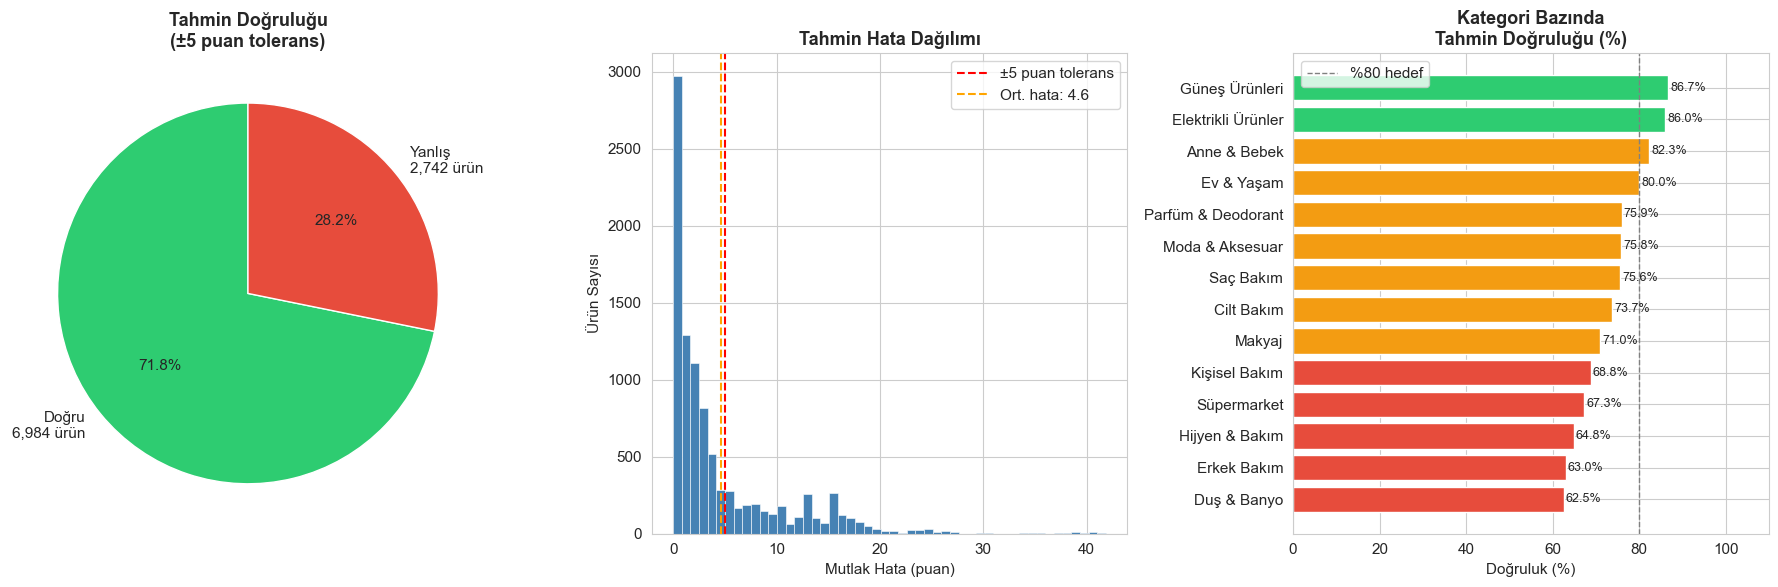

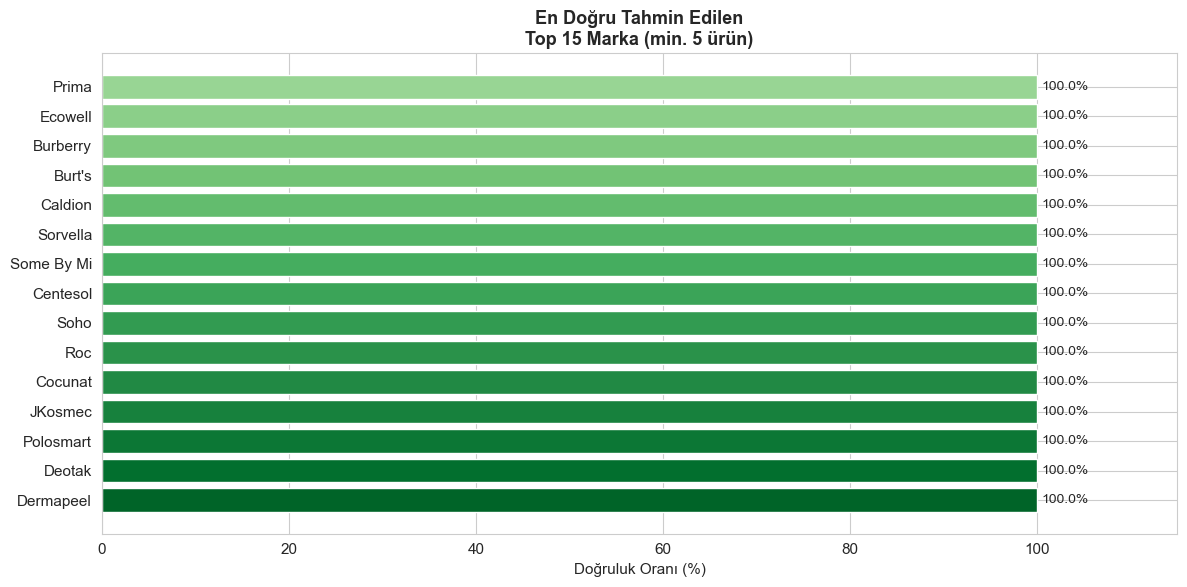

In [38]:
# === DOĞRULUK ANALİZİ VE ÜRÜN BAZLI RAPOR ===

# 1) Validation gerçek değerleri — ürün başına ortalama
gercek_df = (
    val_pivot.groupby('urun_id')['indirim']
    .mean()
    .reset_index()
    .rename(columns={'indirim': 'gercek_indirim'})
)

# 2) Tahmin ve gerçeği birleştir
karsilastirma = sonuc_df[['urun_id', 'isim', 'marka', 'kategori', 'tahmini_indirim']].merge(
    gercek_df, on='urun_id', how='inner'
)

# 3) Hata ve doğruluk hesapla
karsilastirma['hata'] = abs(karsilastirma['tahmini_indirim'] - karsilastirma['gercek_indirim'])
karsilastirma['dogru_mu'] = karsilastirma['hata'] <= 5  # ±5 puan tolerans

# 4) İndirime girecek ürünler tahmini (>%10 indirim beklenen)
indirime_girecek = (
    karsilastirma[karsilastirma['tahmini_indirim'] > 10]
    .sort_values('tahmini_indirim', ascending=False)
    .reset_index(drop=True)
)
indirime_girecek.index += 1

print('=== GELECEKTEKİ HAFTADA İNDİRİME GİRECEK ÜRÜNLER (Tahmin > %10) ===')
print(f'Toplam: {len(indirime_girecek):,} ürün\n')
display(indirime_girecek[['isim', 'marka', 'kategori', 'tahmini_indirim', 'gercek_indirim', 'hata', 'dogru_mu']].head(30))

# 5) Genel doğruluk özeti
dogru_sayisi = karsilastirma['dogru_mu'].sum()
toplam = len(karsilastirma)
print(f'\n=== DOĞRULUK ÖZETİ (±5 puan tolerans) ===')
print(f'Doğru tahmin : {dogru_sayisi:,} ürün ({dogru_sayisi/toplam*100:.1f}%)')
print(f'Yanlış tahmin: {toplam-dogru_sayisi:,} ürün ({(toplam-dogru_sayisi)/toplam*100:.1f}%)')

# 6) Görsel — Doğru/Yanlış pasta + Hata dağılımı
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sol: Pasta grafiği
ax1 = axes[0]
ax1.pie(
    [dogru_sayisi, toplam - dogru_sayisi],
    labels=[f'Doğru\n{dogru_sayisi:,} ürün', f'Yanlış\n{toplam-dogru_sayisi:,} ürün'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
ax1.set_title('Tahmin Doğruluğu\n(±5 puan tolerans)', fontsize=13, fontweight='bold')

# Orta: Hata dağılımı histogram
ax2 = axes[1]
ax2.hist(karsilastirma['hata'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax2.axvline(5, color='red', linestyle='--', linewidth=1.5, label='±5 puan tolerans')
ax2.axvline(karsilastirma['hata'].mean(), color='orange', linestyle='--',
            linewidth=1.5, label=f'Ort. hata: {karsilastirma["hata"].mean():.1f}')
ax2.set_title('Tahmin Hata Dağılımı', fontsize=13, fontweight='bold')
ax2.set_xlabel('Mutlak Hata (puan)')
ax2.set_ylabel('Ürün Sayısı')
ax2.legend()

# Sağ: Kategori bazında doğruluk oranı
ax3 = axes[2]
kat_dogru = (
    karsilastirma.groupby('kategori')['dogru_mu']
    .mean()
    .sort_values()
    .reset_index()
)
colors = ['#e74c3c' if v < 0.7 else '#f39c12' if v < 0.85 else '#2ecc71'
          for v in kat_dogru['dogru_mu']]
ax3.barh(kat_dogru['kategori'], kat_dogru['dogru_mu'] * 100, color=colors)
ax3.axvline(80, color='gray', linestyle='--', linewidth=1, label='%80 hedef')
ax3.set_title('Kategori Bazında\nTahmin Doğruluğu (%)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Doğruluk (%)')
ax3.set_xlim(0, 110)
for bar, val in zip(ax3.patches, kat_dogru['dogru_mu']):
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=9)
ax3.legend()

plt.tight_layout()
plt.show()

# 7) Marka bazında en iyi tahmin edilen markalar
marka_dogru = (
    karsilastirma.groupby('marka')
    .agg(dogru_oran=('dogru_mu', 'mean'), urun_sayisi=('urun_id', 'count'))
    .query('urun_sayisi >= 5')
    .sort_values('dogru_oran', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(marka_dogru['marka'], marka_dogru['dogru_oran'] * 100,
               color=plt.cm.Greens(np.linspace(0.4, 0.9, len(marka_dogru))))
ax.set_title('En Doğru Tahmin Edilen\nTop 15 Marka (min. 5 ürün)', fontsize=13, fontweight='bold')
ax.set_xlabel('Doğruluk Oranı (%)')
ax.set_xlim(0, 115)
for bar, val in zip(ax.patches, marka_dogru['dogru_oran']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Gelecek Hafta En Yüksek İndirim Beklenen Ürünler

Bu bölümde modelin ürettiği tahminler sıralanarak gelecek haftada en yüksek indirim beklenen ilk 20 ürün listelenmektedir.

**Yapılan adımlar:**

1. **Kategori düzeltmesi:** Birleştirme işlemlerinden kaynaklanan `kategori_x` / `kategori_y` çakışması giderilerek tek bir `kategori` sütunu oluşturulmaktadır.

2. **Sıralama ve filtreleme:** Tüm ürünler tahmini indirim oranına göre büyükten küçüğe sıralanmakta ve ilk 20 ürün seçilmektedir.

3. **Tablo sunumu:** Sonuç tablosu okunabilirlik için sütun adları Türkçeleştirilerek `display` ile gösterilmektedir. Her satırda ürün adı, marka, kategori, son hafta gerçek indirimi, tahmini indirim ve küme bilgisi yer almaktadır.

**Kullanım amacı:** Bu tablo, tüketiciye yönelik en doğrudan çıktıdır — hangi ürünlerin gelecek hafta indirime gireceğini somut olarak göstermektedir. `lag_1w_indirim` sütunu modelin tahmini geçmiş hafta verisinden ne kadar saptığını karşılaştırmalı olarak görmeyi sağlar.

In [39]:
# Kategori sütununu düzelt
sonuc_df['kategori'] = sonuc_df['kategori_y'].fillna(sonuc_df['kategori_x'])

# En yüksek indirim beklenen ürünler
top_indirim = (
    sonuc_df[['urun_id', 'isim', 'marka', 'kategori', 'lag_1w_indirim', 'tahmini_indirim', 'cluster_adi']]
    .sort_values('tahmini_indirim', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

top_indirim.index += 1
print('=== GELECEKTEKİ HAFTADA EN YÜKSEK İNDİRİM BEKLENTİSİ ===')
display(top_indirim.rename(columns={
    'isim': 'Ürün Adı',
    'marka': 'Marka',
    'kategori': 'Kategori',
    'lag_1w_indirim': 'Son Hafta İndirimi (%)',
    'tahmini_indirim': 'Tahmini İndirim (%)',
    'cluster_adi': 'Küme'
}))

=== GELECEKTEKİ HAFTADA EN YÜKSEK İNDİRİM BEKLENTİSİ ===


,urun_id,Ürün Adı,Marka,Kategori,Son Hafta İndirimi (%),Tahmini İndirim (%),Küme
1,10211746,Eklips Simli Pembe Bere,Eklips,Moda & Aksesuar,84.000000,82.902083,Sürekli İndirimli Ana Katalog Ürünleri
2,10204130,Eklips Leopar Bere,Eklips,Moda & Aksesuar,84.000000,82.902083,Sürekli İndirimli Ana Katalog Ürünleri
3,10211749,Eklips Simli Bej Bere,Eklips,Moda & Aksesuar,84.000000,82.902083,Sürekli İndirimli Ana Katalog Ürünleri
4,10211748,Eklips Simli Gri Bere,Eklips,Moda & Aksesuar,84.000000,82.902083,Sürekli İndirimli Ana Katalog Ürünleri
5,10216935,Maruderm Biberiye & Pantenol Biberiye Saç Krem...,Maruderm,Saç Bakım,83.000000,82.824578,Sürekli İndirimli Ana Katalog Ürünleri
6,10199513,Himalaya Leke Karşıtı Zerdeçal Özlü Yüz Kremi ...,Himalaya,Cilt Bakım,83.900000,82.555329,Sürekli İndirimli Ana Katalog Ürünleri
7,10211234,Loshel Keratin Saç Serumu 100 ml,Loshel,Saç Bakım,82.900000,82.410682,Sürekli İndirimli Ana Katalog Ürünleri
8,10204129,Eklips Zigzag Bere (Asortili),Eklips,Moda & Aksesuar,84.000000,82.372998,Sürekli İndirimli Ana Katalog Ürünleri
9,10204132,Eklips Çizgili Bere (Asortili),Eklips,Moda & Aksesuar,84.000000,82.372998,Sürekli İndirimli Ana Katalog Ürünleri
10,10204133,Eklips Zebra Bere (Asortili),Eklips,Moda & Aksesuar,84.000000,82.372998,Sürekli İndirimli Ana Katalog Ürünleri


## Kategori Bazında Gelecek Hafta Tahmini İndirim

Bu bölümde modelin ürettiği tahminler kategori düzeyinde özetlenerek görselleştirilmektedir.

**Yapılan adımlar:**

1. **Gruplama:** Ürün bazındaki tahminler kategoriye göre gruplanarak her kategori için ortalama tahmini indirim hesaplanmaktadır.

2. **Sıralama:** Kategoriler ortalama tahmini indirimi yüksekten düşüğe doğru sıralanmaktadır.

3. **Görsel:** Yatay bar grafiğinde her çubuk bir kategoriyi temsil etmekte, renk skalası (`RdYlGn_r`) yüksek indirimden düşük indirime doğru kırmızıdan yeşile geçmektedir. Her çubuğun ucuna yüzde değeri etiket olarak eklenmektedir.

**Kullanım amacı:** Hangi kategorilerde gelecek hafta daha güçlü indirim beklediğini tek bakışta görmek için kullanılır. Kategori bazlı alışveriş planlaması yapan kullanıcılar için yönlendirici bir özet sunar.

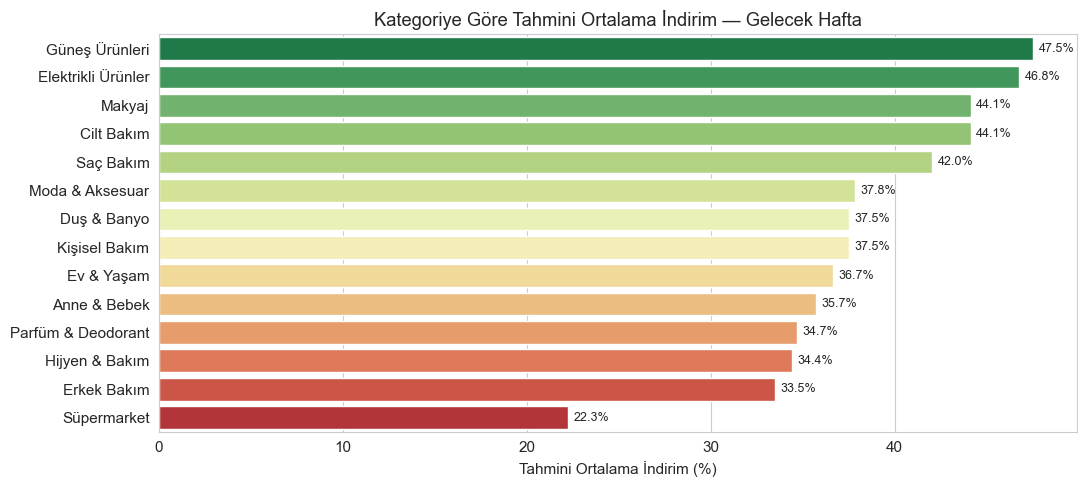

In [40]:
# Kategori bazında gelecek hafta tahmini
kat_tahmin = (
    sonuc_df.groupby('kategori')['tahmini_indirim']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=kat_tahmin, y='kategori', x='tahmini_indirim', palette='RdYlGn_r', ax=ax)
ax.set_title('Kategoriye Göre Tahmini Ortalama İndirim — Gelecek Hafta')
ax.set_xlabel('Tahmini Ortalama İndirim (%)')
ax.set_ylabel('')
for bar, val in zip(ax.patches, kat_tahmin['tahmini_indirim']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Tahmin Sonuçlarının Kaydedilmesi

Bu bölümde modelin ürettiği tahminler CSV dosyasına yazılmaktadır.

**Yapılan adımlar:**

1. **Sütun seçimi:** Sonuç tablosundan yalnızca anlamlı ve kullanıcıya yönelik sütunlar seçilmektedir — ürün kimliği, isim, marka, kategori, geçmiş indirim değerleri, küme bilgisi ve tahmini indirim.

2. **Sıralama:** Kayıt, tahmini indirim oranına göre büyükten küçüğe sıralanarak dosyaya yazılmaktadır; en cazip ürünler listenin üstünde yer alır.

3. **Kayıt:** `utf-8-sig` encoding kullanılmaktadır — bu sayede dosya Excel'de Türkçe karakterler bozulmadan açılabilir.

4. **Doğrulama çıktısı:** Dosya yolu ve kayıt sayısı ekrana yazdırılarak işlemin başarıyla tamamlandığı teyit edilmektedir.

**Çıktı dosyasındaki sütunlar:**

| Sütun | Açıklama |
|---|---|
| `lag_1w_indirim` / `lag_2w_indirim` | Son 1-2 haftanın gerçek indirim oranı |
| `max_indirim_train` | Eğitim dönemindeki maksimum indirim |
| `indirimli_gun_orani` | Ürünün geçmişte indirimde olduğu gün oranı |
| `cluster_adi` | Ürünün ait olduğu davranış kümesi |
| `tahmini_indirim` | Modelin gelecek hafta için ürettiği tahmin |

In [41]:
# Sonuçları kaydet
CIKTI_PATH = DATA_DIR / 'gelecek_hafta_indirim_tahmini.csv'

kayit_df = sonuc_df[[
    'urun_id', 'isim', 'marka', 'kategori',
    'lag_1w_indirim', 'lag_2w_indirim',
    'max_indirim_train', 'indirimli_gun_orani',
    'cluster_adi', 'tahmini_indirim'
]].sort_values('tahmini_indirim', ascending=False)

kayit_df.to_csv(CIKTI_PATH, index=False, encoding='utf-8-sig')
print(f'Tahmin dosyası kaydedildi ✓')
print(f'Dosya yolu: {CIKTI_PATH}')
print(f'Kayıt sayısı: {len(kayit_df):,}')

Tahmin dosyası kaydedildi ✓
Dosya yolu: /Users/damlasimsek/Desktop/GRATİSVERİ/processed/gelecek_hafta_indirim_tahmini.csv
Kayıt sayısı: 10,088


---

## Notebook Özeti

### Yapılan İşlemler

1. Temiz veri ve küme bilgisi okundu.
2. **İlk 3 hafta** train, **son 1 hafta** validation olarak ayrıldı.
3. Her ürün için lag özellikleri (son 1, 2, 3 hafta ortalamaları), rolling std, max indirim, kampanya oranı ve küme bilgisi hesaplandı.
4. **Random Forest Regressor** ile model eğitildi.
5. MAE, RMSE ve R² metrikleri ile model değerlendirildi.
6. Özellik önemi analiz edildi — lag_1w_indirim baskın özellik.
7. Tüm veri üzerinden **gelecek hafta tahminleri** üretildi.
8. Sonuçlar `gelecek_hafta_indirim_tahmini.csv` dosyasına kaydedildi.

### Güçlü Yönler
- Zaman bilgisi sızdırmıyor (temporal split)
- Küme ve kategori bilgisini kullanıyor
- Yorumlanabilir özellikler

### Geliştirme Önerileri
- LightGBM / XGBoost ile karşılaştırma
- Ürün başına ayrı zaman serisi modeli (yeterli gözlem varsa)
- Kampanya tipi one-hot encoding
- Yeni veri geldiğinde model otomatik yeniden eğitimi

## Streamlit Uygulaması — app.py Oluşturma

Bu hücrede projenin tüm analiz çıktılarını interaktif bir web arayüzünde sunan Streamlit uygulaması `app.py` dosyasına yazılmaktadır.

---

**Uygulama yapısı — 4 sayfa:**

**🏠 Genel Özet**
Takip edilen ürün sayısı, indirim beklenen ürün oranı, ortalama ve maksimum tahmin gibi özet metrikler kart formatında sunulmaktadır. Kategori bazında tahmini indirim grafiği ve en yüksek indirim beklenen ilk 20 ürün tablosu yan yana gösterilmektedir.

**🔍 Ürün Ara**
Kullanıcı ürün adı veya marka yazarak arama yapabilmekte, kategori filtresi uygulayabilmektedir. Sonuçlar tahmini indirime göre sıralanmakta; "İndirime giriyor", "Takipte tut", "İndirim beklenmiyor" durumları renkli etiketlerle gösterilmektedir.

**📊 Kategori & Küme Analizi**
Küme × Kategori heatmap, top 15 marka bar grafiği ve durum dağılımı kart metrikleri bu sayfada yer almaktadır.

**🤖 Model Performansı**
MAE, RMSE ve R² metrikleri kart olarak sunulmaktadır. Tahmin doğruluğu pasta grafiği, kategori bazında doğruluk bar grafiği ve hata dağılımı histogramı bu sayfada görselleştirilmektedir.

---

**Teknik detaylar:**

- `@st.cache_data` ile CSV dosyaları önbelleğe alınarak her sayfa geçişinde yeniden okunması engellenmektedir.
- `@st.cache_resource` ile Random Forest modeli bir kez eğitilip bellekte tutulmaktadır.
- Kategori sütunu birleştirme kaynaklı `kategori_x` / `kategori_y` çakışması uygulama başlangıcında temizlenmektedir.
- Uygulama kodu string olarak tanımlanıp `APP_DIR/app.py` dosyasına yazılmaktadır; çalıştırmak için terminalde `streamlit run app.py` komutu kullanılır.

In [7]:
from pathlib import Path
app_kodu = '''import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

st.set_page_config(page_title="Gratis İndirim Takip", page_icon="🏷️", layout="wide")

st.markdown("""
<style>
.metric-card { background:#f8f9fa; border-radius:10px; padding:16px; text-align:center; border:1px solid #e9ecef; }
.metric-label { font-size:12px; color:#6c757d; margin-bottom:4px; }
.metric-value { font-size:28px; font-weight:600; color:#212529; }
.metric-sub   { font-size:11px; color:#28a745; margin-top:2px; }
</style>
""", unsafe_allow_html=True)

DATA_DIR = Path("data")

@st.cache_data
def load_data():
    ozet     = pd.read_csv(DATA_DIR/"ozet.csv", encoding="utf-8-sig")
    tahmin   = pd.read_csv(DATA_DIR/"gelecek_hafta_indirim_tahmini.csv", encoding="utf-8-sig")
    kume     = pd.read_csv(DATA_DIR/"urun_kumeleri.csv", encoding="utf-8-sig")
    dogruluk = pd.read_csv(DATA_DIR/"dogruluk_analizi.csv", encoding="utf-8-sig")
    return ozet, tahmin, kume, dogruluk

@st.cache_resource
def load_model():
    tahmin = pd.read_csv(DATA_DIR/"gelecek_hafta_indirim_tahmini.csv", encoding="utf-8-sig")
    dogruluk = pd.read_csv(DATA_DIR/"dogruluk_analizi.csv", encoding="utf-8-sig")
    if "kategori_y" in tahmin.columns:
        tahmin["kategori"] = tahmin["kategori_y"].fillna(tahmin.get("kategori_x",""))
    elif "kategori_x" in tahmin.columns:
        tahmin["kategori"] = tahmin["kategori_x"]
    le = LabelEncoder()
    dogruluk["kategori_enc"] = le.fit_transform(dogruluk["kategori"].fillna("Bilinmiyor")) if "kategori" in dogruluk.columns else 0
    FEATURE_COLS = [c for c in ["lag_1w_indirim","lag_2w_indirim","lag_3w_indirim",
                                 "rolling_std_indirim","max_indirim_train","indirimli_gun_orani",
                                 "kampanyali_gun_orani","gozlem_sayisi","cluster","kategori_enc"]
                    if c in tahmin.columns]
    if len(FEATURE_COLS) < 3:
        return None
    X = tahmin[FEATURE_COLS].fillna(0)
    y = tahmin["tahmini_indirim"]
    model = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
    model.fit(X, y)
    return model

ozet_df, tahmin_df, kume_df, dogruluk_df = load_data()

with st.spinner("Model yükleniyor..."):
    model = load_model()

if "kategori_y" in tahmin_df.columns:
    tahmin_df["kategori"] = tahmin_df["kategori_y"].fillna(tahmin_df.get("kategori_x",""))
elif "kategori_x" in tahmin_df.columns:
    tahmin_df["kategori"] = tahmin_df["kategori_x"]

def indirim_etiketi(val):
    if val >= 40:   return "İndirime giriyor"
    elif val >= 15: return "Takipte tut"
    else:           return "İndirim beklenmiyor"

tahmin_df["durum"] = tahmin_df["tahmini_indirim"].apply(indirim_etiketi)
son_guncelleme = ozet_df["son_guncelleme"].iloc[0]
toplam_kayit   = int(ozet_df["toplam_kayit"].iloc[0])

with st.sidebar:
    st.markdown("### 🏷️ Gratis Takip")
    st.markdown("İndirim tahmin sistemi")
    st.markdown("---")
    sayfa = st.radio("Sayfa seç", [
        "🏠 Genel Özet", "🔍 Ürün Ara",
        "📊 Kategori Analizi", "🤖 Model Performansı"
    ], label_visibility="collapsed")
    st.markdown("---")
    st.markdown(f"**Son güncelleme:** {son_guncelleme}")
    st.markdown(f"**Toplam kayıt:** {toplam_kayit:,}")
    st.markdown(f"**Takip edilen ürün:** {len(tahmin_df):,}")

if sayfa == "🏠 Genel Özet":
    st.title("Genel Özet")
    st.caption("Gelecek hafta için tahmin edilen indirim durumu")
    indirime_giren = (tahmin_df["tahmini_indirim"] >= 40).sum()
    ort_indirim    = tahmin_df["tahmini_indirim"].mean()
    max_indirim    = tahmin_df["tahmini_indirim"].max()
    toplam_urun    = len(tahmin_df)
    c1,c2,c3,c4 = st.columns(4)
    for col, label, val, sub in [
        (c1, "Takip edilen ürün",    f"{toplam_urun:,}",       ""),
        (c2, "İndirim beklenen",     f"{indirime_giren:,}",    f"%{indirime_giren/toplam_urun*100:.1f} oran"),
        (c3, "Ort. tahmini indirim", f"%{ort_indirim:.1f}",    ""),
        (c4, "En yüksek tahmin",     f"%{max_indirim:.1f}",    ""),
    ]:
        with col:
            st.markdown(f"""<div class="metric-card">
                <div class="metric-label">{label}</div>
                <div class="metric-value">{val}</div>
                <div class="metric-sub">{sub}</div>
            </div>""", unsafe_allow_html=True)
    st.markdown("<br>", unsafe_allow_html=True)
    col_l, col_r = st.columns(2)
    with col_l:
        st.subheader("Kategori bazında tahmini indirim")
        kat = tahmin_df.groupby("kategori")["tahmini_indirim"].mean().sort_values(ascending=True).reset_index()
        fig, ax = plt.subplots(figsize=(7,5))
        ax.barh(kat["kategori"], kat["tahmini_indirim"], color=plt.cm.Blues(np.linspace(0.4,0.85,len(kat))))
        for b,v in zip(ax.patches, kat["tahmini_indirim"]):
            ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2, f"%{v:.1f}", va="center", fontsize=9)
        ax.set_xlabel("Tahmini Ortalama İndirim (%)"); ax.set_xlim(0, kat["tahmini_indirim"].max()*1.2)
        ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); st.pyplot(fig); plt.close()
    with col_r:
        st.subheader("En yüksek indirim beklenen 20 ürün")
        top20 = (tahmin_df[["isim","marka","kategori","tahmini_indirim","durum","cluster_adi"]]
                 .sort_values("tahmini_indirim", ascending=False).head(20).reset_index(drop=True))
        top20.index += 1
        top20.columns = ["Ürün Adı","Marka","Kategori","Tahmini İndirim (%)","Durum","Küme"]
        st.dataframe(top20, use_container_width=True, height=380)

elif sayfa == "🔍 Ürün Ara":
    st.title("Ürün Ara")
    c1,c2 = st.columns([2,1])
    with c1:
        arama = st.text_input("Ürün adı veya marka", placeholder="Örn: Flormar, maskara, Nivea...")
    with c2:
        kat_f = st.selectbox("Kategori", ["Tümü"] + sorted(tahmin_df["kategori"].dropna().unique().tolist()))
    sonuc = tahmin_df.copy()
    if arama:
        sonuc = sonuc[sonuc["isim"].str.contains(arama, case=False, na=False) |
                      sonuc["marka"].str.contains(arama, case=False, na=False)]
    if kat_f != "Tümü":
        sonuc = sonuc[sonuc["kategori"] == kat_f]
    sonuc = sonuc.sort_values("tahmini_indirim", ascending=False).reset_index(drop=True)
    sonuc.index += 1
    st.markdown(f"**{len(sonuc):,} ürün bulundu**")
    if len(sonuc):
        goster = sonuc[["isim","marka","kategori","tahmini_indirim","durum","cluster_adi"]].copy()
        goster.columns = ["Ürün Adı","Marka","Kategori","Tahmini İndirim (%)","Durum","Küme"]
        def renk(val):
            if val == "İndirime giriyor": return "background-color:#d4edda;color:#155724"
            elif val == "Takipte tut":    return "background-color:#fff3cd;color:#856404"
            return "background-color:#f8d7da;color:#721c24"
        st.dataframe(goster.style.applymap(renk, subset=["Durum"]), use_container_width=True, height=500)
    else:
        st.info("Arama kriterlerine uygun ürün bulunamadı.")

elif sayfa == "📊 Kategori Analizi":
    st.title("Kategori & Küme Analizi")
    col_l, col_r = st.columns(2)
    with col_l:
        st.subheader("Küme × Kategori heatmap")
        pivot = tahmin_df.groupby(["cluster_adi","kategori"])["tahmini_indirim"].mean().unstack(fill_value=0)
        fig, ax = plt.subplots(figsize=(7,4))
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=ax,
                    cbar_kws={"label":"Tahmini İndirim (%)"})
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
        plt.tight_layout(); st.pyplot(fig); plt.close()
    with col_r:
        st.subheader("Top 15 marka — tahmini indirim")
        marka = (tahmin_df.groupby("marka")
                 .agg(ort=("tahmini_indirim","mean"), n=("urun_id","count"))
                 .query("n >= 3").sort_values("ort", ascending=True).tail(15).reset_index())
        fig, ax = plt.subplots(figsize=(7,5))
        ax.barh(marka["marka"], marka["ort"], color=plt.cm.Oranges(np.linspace(0.4,0.85,len(marka))))
        for b,v in zip(ax.patches, marka["ort"]):
            ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2, f"%{v:.1f}", va="center", fontsize=9)
        ax.set_xlabel("Tahmini Ortalama İndirim (%)"); ax.set_xlim(0, marka["ort"].max()*1.2)
        ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); st.pyplot(fig); plt.close()
    st.subheader("Durum dağılımı")
    durum = tahmin_df["durum"].value_counts().reset_index()
    durum.columns = ["Durum","Ürün Sayısı"]
    renkler = {"İndirime giriyor":("#d4edda","#155724"),
               "Takipte tut":("#fff3cd","#856404"),
               "İndirim beklenmiyor":("#f8d7da","#721c24")}
    cols = st.columns(len(durum))
    for i, (_,row) in enumerate(durum.iterrows()):
        bg,fg = renkler.get(row["Durum"],("#f8f9fa","#212529"))
        with cols[i]:
            st.markdown(f"""<div class="metric-card" style="background:{bg}">
                <div class="metric-label" style="color:{fg}">{row["Durum"]}</div>
                <div class="metric-value" style="color:{fg}">{row["Ürün Sayısı"]:,}</div>
            </div>""", unsafe_allow_html=True)

elif sayfa == "🤖 Model Performansı":
    st.title("Model Performansı")
    st.caption("Validation haftası tahmin doğruluğu")
    c1,c2,c3 = st.columns(3)
    for col,lbl,val,sub in [
        (c1,"MAE","2.20","±2.2 puan hata payı"),
        (c2,"RMSE","4.46",""),
        (c3,"R²","0.923","%92.3 doğruluk"),
    ]:
        with col:
            st.markdown(f"""<div class="metric-card">
                <div class="metric-label">{lbl}</div>
                <div class="metric-value">{val}</div>
                <div class="metric-sub">{sub}</div>
            </div>""", unsafe_allow_html=True)
    st.markdown("<br>", unsafe_allow_html=True)
    col_l,col_r = st.columns(2)
    with col_l:
        st.subheader("Tahmin doğruluğu (±5 puan)")
        dogru  = int(dogruluk_df["dogru_mu"].sum())
        yanlis = len(dogruluk_df) - dogru
        fig,ax = plt.subplots(figsize=(5,4))
        ax.pie([dogru,yanlis], labels=[f"Doğru\\n{dogru:,}",f"Yanlış\\n{yanlis:,}"],
               colors=["#28a745","#dc3545"], autopct="%1.1f%%", startangle=90,
               textprops={"fontsize":11})
        plt.tight_layout(); st.pyplot(fig); plt.close()
    with col_r:
        st.subheader("Kategori bazında doğruluk")
        kd = dogruluk_df.groupby("kategori")["dogru_mu"].mean().sort_values().reset_index()
        fig,ax = plt.subplots(figsize=(6,4))
        renkler = ["#dc3545" if v<0.7 else "#ffc107" if v<0.85 else "#28a745" for v in kd["dogru_mu"]]
        ax.barh(kd["kategori"], kd["dogru_mu"]*100, color=renkler)
        ax.axvline(80, color="gray", linestyle="--", linewidth=1)
        ax.set_xlabel("Doğruluk (%)")
        for b,v in zip(ax.patches, kd["dogru_mu"]):
            ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f"%{v*100:.1f}", va="center", fontsize=9)
        ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); st.pyplot(fig); plt.close()
    st.subheader("Hata dağılımı")
    fig,ax = plt.subplots(figsize=(10,3))
    ax.hist(dogruluk_df["hata"], bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.axvline(5, color="red", linestyle="--", linewidth=1.5, label="±5 puan tolerans")
    ax.axvline(dogruluk_df["hata"].mean(), color="orange", linestyle="--",
               linewidth=1.5, label=f"Ort. hata: {dogruluk_df[\'hata\'].mean():.1f}")
    ax.set_xlabel("Mutlak Hata (puan)"); ax.set_ylabel("Ürün Sayısı")
    ax.legend(); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); st.pyplot(fig); plt.close()
'''

APP_DIR = Path('/Users/damlasimsek/Desktop/gratis_app')
with open(APP_DIR / 'app.py', 'w', encoding='utf-8') as f:
    f.write(app_kodu)
print('app.py güncellendi ✓')

app.py güncellendi ✓
